# KL Divergence

## Real-World Scenario: Comparing Gene Expression Distributions Across Tissues

A pathology lab needs to quantify how gene expression distributions **shift** between healthy and diseased tissue. KL divergence measures the "extra bits" needed when using one distribution as a model for another — a natural way to detect and quantify distributional changes.

We cover all of PML Section 6.2: definition, interpretation, KL between Gaussians, non-negativity (Jensen's inequality), the connection to MLE, and forward vs reverse KL.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'


def entropy(p):
    """Discrete entropy H(X) = -sum p_k log2 p_k (Eq. 6.1)."""
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return -np.sum(p * np.log2(p))


def cross_entropy(p, q):
    """Cross entropy H_ce(p, q) = -sum p_k log2 q_k (Eq. 6.7)."""
    p, q = np.asarray(p, dtype=float), np.asarray(q, dtype=float)
    q = np.clip(q, 1e-15, None)
    mask = p > 0
    return -np.sum(p[mask] * np.log2(q[mask]))

## Key Formulas from PML Section 6.2

| Concept | Formula | Eq. |
|---------|---------|-----|
| KL divergence | $D_{\text{KL}}(p \| q) = \sum_k p_k \log \frac{p_k}{q_k} = -H(p) + H_{\text{ce}}(p, q)$ | 6.30–6.31 |
| KL (1D Gaussian) | $\log(\sigma_2/\sigma_1) + (\sigma_1^2 + (\mu_1-\mu_2)^2)/(2\sigma_2^2) - 1/2$ | 6.33 |
| KL (multivariate Gaussian) | $\frac{1}{2}[\text{tr}(\Sigma_2^{-1}\Sigma_1) + (\mu_2-\mu_1)^T\Sigma_2^{-1}(\mu_2-\mu_1) - D + \log\frac{\det\Sigma_2}{\det\Sigma_1}]$ | 6.32 |
| Jensen's inequality | $f(E[X]) \leq E[f(X)]$ for convex $f$ | 6.34 |
| KL and MLE | $D_{\text{KL}}(p_D \| q) = -\frac{1}{N}\sum_n \log q(x_n) + C$ | 6.44 |

## 9. KL Divergence Definition (Section 6.2.1)

The Kullback-Leibler divergence from $p$ to $q$ (Eq. 6.30):

$$D_{\text{KL}}(p \| q) = \sum_k p_k \log \frac{p_k}{q_k} = -H(p) + H_{\text{ce}}(p, q)$$

Properties:
- $D_{\text{KL}}(p \| q) \geq 0$ with equality iff $p = q$ (**Gibbs' inequality**, Theorem 6.2.1)
- **Not symmetric**: $D_{\text{KL}}(p \| q) \neq D_{\text{KL}}(q \| p)$ in general
- Interpretation: the **extra bits** needed when using code $q$ instead of optimal code $p$ (Eq. 6.31)

In [2]:
def kl_divergence(p, q):
    """KL divergence D_KL(p || q) in bits (Eq. 6.30)."""
    p, q = np.asarray(p, dtype=float), np.asarray(q, dtype=float)
    q = np.clip(q, 1e-15, None)
    mask = p > 0
    return np.sum(p[mask] * np.log2(p[mask] / q[mask]))


# Compare gene expression distributions between healthy and diseased tissue
p_healthy = np.array([0.60, 0.25, 0.10, 0.05])  # mostly quiescent
p_tumor = np.array([0.10, 0.50, 0.25, 0.15])    # mostly proliferating
p_inflamed = np.array([0.15, 0.15, 0.55, 0.15])  # mostly stressed

tissues = {
    'Healthy': p_healthy,
    'Tumor': p_tumor,
    'Inflamed': p_inflamed,
}

print('KL Divergence between tissue types (bits):')
print(f'{"":12s}', end='')
for name in tissues:
    print(f'{name:>12s}', end='')
print()

for name_p, p in tissues.items():
    print(f'{name_p:12s}', end='')
    for name_q, q in tissues.items():
        kl = kl_divergence(p, q)
        print(f'{kl:12.4f}', end='')
    print()

print(f'\nNote: D_KL(Healthy || Tumor) = {kl_divergence(p_healthy, p_tumor):.4f}')
print(f'      D_KL(Tumor || Healthy) = {kl_divergence(p_tumor, p_healthy):.4f}')
print('KL divergence is NOT symmetric.')

KL Divergence between tissue types (bits):
                 Healthy       Tumor    Inflamed
Healthy           0.0000      1.0895      1.0591
Tumor             0.8097      0.0000      0.5256
Inflamed          1.1799      0.4528      0.0000

Note: D_KL(Healthy || Tumor) = 1.0895
      D_KL(Tumor || Healthy) = 0.8097
KL divergence is NOT symmetric.


## 10. Non-negativity of KL (Jensen's Inequality) (Section 6.2.4)

**Theorem 6.2.1** (Information inequality): $D_{\text{KL}}(p \| q) \geq 0$ with equality iff $p = q$.

The proof uses **Jensen's inequality**: for a convex function $f$,

$$f\left(\sum_i \lambda_i x_i\right) \leq \sum_i \lambda_i f(x_i)$$

Since $-\log$ is convex (Eq. 6.35):

$$-D_{\text{KL}}(p \| q) = \sum_x p(x) \log \frac{q(x)}{p(x)} \leq \log \sum_x q(x) = \log 1 = 0$$

**Corollary** (Eq. 6.39): The uniform distribution maximizes entropy: $H(X) \leq \log |\mathcal{X}|$.

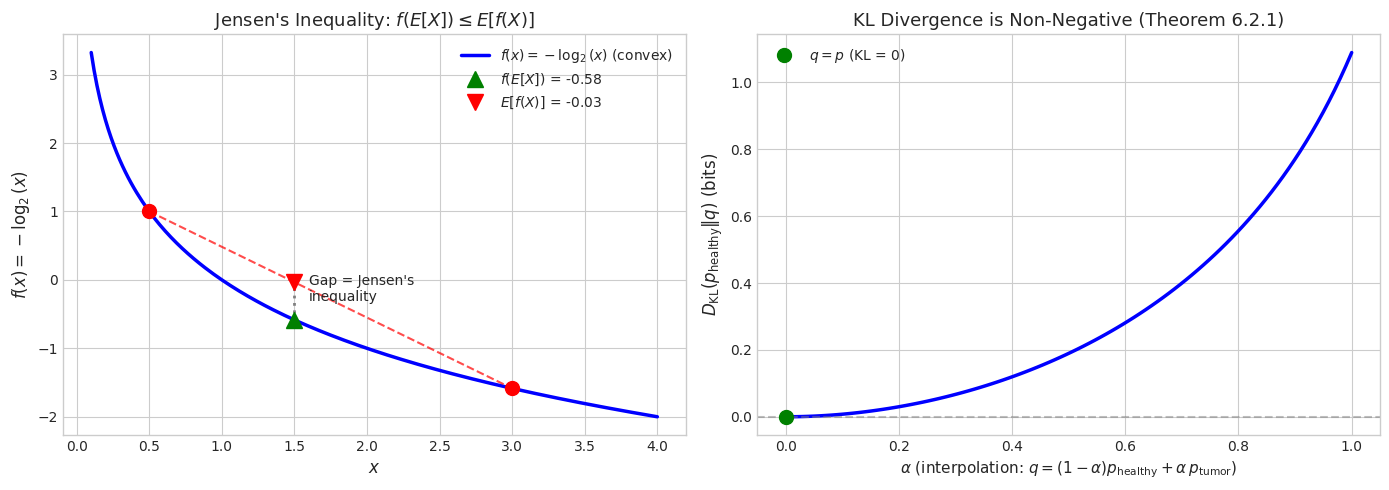

In [3]:
# Visualize Jensen's inequality: E[f(X)] >= f(E[X]) for convex f
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Jensen's inequality for f(x) = -log(x)
x_range = np.linspace(0.1, 4, 200)
f_x = -np.log2(x_range)

axes[0].plot(x_range, f_x, 'b-', linewidth=2.5, label='$f(x) = -\\log_2(x)$ (convex)')

# Two points with weights
x_pts = np.array([0.5, 3.0])
lam = np.array([0.6, 0.4])
f_pts = -np.log2(x_pts)
x_avg = np.sum(lam * x_pts)
f_avg = -np.log2(x_avg)
avg_f = np.sum(lam * f_pts)

axes[0].plot(x_pts, f_pts, 'ro', markersize=10, zorder=5)
axes[0].plot([x_pts[0], x_pts[1]], [f_pts[0], f_pts[1]], 'r--', linewidth=1.5, alpha=0.7)
axes[0].plot(x_avg, f_avg, 'g^', markersize=12, zorder=5, label=f'$f(E[X])$ = {f_avg:.2f}')
axes[0].plot(x_avg, avg_f, 'rv', markersize=12, zorder=5, label=f'$E[f(X)]$ = {avg_f:.2f}')
axes[0].vlines(x_avg, f_avg, avg_f, colors='gray', linestyles=':', linewidths=2)
axes[0].annotate('Gap = Jensen\'s\ninequality', xy=(x_avg + 0.1, (f_avg + avg_f) / 2),
                fontsize=10)

axes[0].set_xlabel('$x$', fontsize=12)
axes[0].set_ylabel('$f(x) = -\\log_2(x)$', fontsize=12)
axes[0].set_title("Jensen's Inequality: $f(E[X]) \\leq E[f(X)]$", fontsize=13)
axes[0].legend(fontsize=10)

# Right: KL divergence is always non-negative
# Interpolate between p_healthy and p_tumor
alphas = np.linspace(0, 1, 100)
kl_values = []
for alpha in alphas:
    q_interp = (1 - alpha) * p_healthy + alpha * p_tumor
    kl_values.append(kl_divergence(p_healthy, q_interp))

axes[1].plot(alphas, kl_values, 'b-', linewidth=2.5)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].plot(0, 0, 'go', markersize=10, zorder=5, label='$q = p$ (KL = 0)')

axes[1].set_xlabel('$\\alpha$ (interpolation: $q = (1-\\alpha)p_{\\mathrm{healthy}} + \\alpha \\, p_{\\mathrm{tumor}}$)',
                  fontsize=11)
axes[1].set_ylabel('$D_{\\mathrm{KL}}(p_{\\mathrm{healthy}} \\| q)$ (bits)', fontsize=12)
axes[1].set_title('KL Divergence is Non-Negative (Theorem 6.2.1)', fontsize=13)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

## 11. KL Divergence Between Two Gaussians (Section 6.2.3)

For univariate Gaussians (Eq. 6.33):

$$D_{\text{KL}}(\mathcal{N}(\mu_1, \sigma_1^2) \| \mathcal{N}(\mu_2, \sigma_2^2)) = \log \frac{\sigma_2}{\sigma_1} + \frac{\sigma_1^2 + (\mu_1 - \mu_2)^2}{2\sigma_2^2} - \frac{1}{2}$$

For multivariate Gaussians (Eq. 6.32):

$$D_{\text{KL}}(\mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1) \| \mathcal{N}(\boldsymbol{\mu}_2, \boldsymbol{\Sigma}_2)) = \frac{1}{2}\left[\text{tr}(\boldsymbol{\Sigma}_2^{-1}\boldsymbol{\Sigma}_1) + (\boldsymbol{\mu}_2 - \boldsymbol{\mu}_1)^T \boldsymbol{\Sigma}_2^{-1} (\boldsymbol{\mu}_2 - \boldsymbol{\mu}_1) - D + \log\frac{\det(\boldsymbol{\Sigma}_2)}{\det(\boldsymbol{\Sigma}_1)}\right]$$

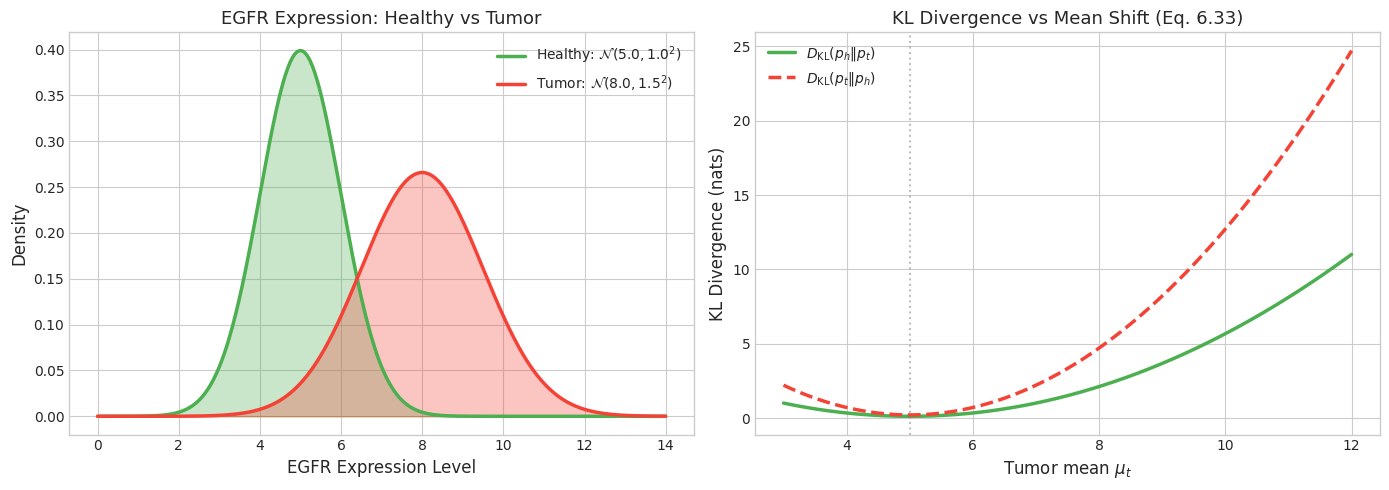

D_KL(Healthy || Tumor) = 2.1277 nats
D_KL(Tumor || Healthy) = 4.7195 nats
Asymmetry: the KL depends on which distribution is the "reference".


In [4]:
def kl_gaussians_1d(mu1, sigma1, mu2, sigma2):
    """KL divergence between two 1D Gaussians in nats (Eq. 6.33)."""
    return (np.log(sigma2 / sigma1)
            + (sigma1**2 + (mu1 - mu2)**2) / (2 * sigma2**2)
            - 0.5)


# Gene expression levels: healthy vs tumor tissue
mu_h, sigma_h = 5.0, 1.0   # healthy: EGFR expression ~ N(5, 1)
mu_t, sigma_t = 8.0, 1.5   # tumor: EGFR overexpressed ~ N(8, 1.5)

kl_h_to_t = kl_gaussians_1d(mu_h, sigma_h, mu_t, sigma_t)
kl_t_to_h = kl_gaussians_1d(mu_t, sigma_t, mu_h, sigma_h)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(0, 14, 500)
p_h = stats.norm.pdf(x, mu_h, sigma_h)
p_t = stats.norm.pdf(x, mu_t, sigma_t)

# Left: the two distributions
axes[0].fill_between(x, p_h, alpha=0.3, color='#4CAF50')
axes[0].plot(x, p_h, '#4CAF50', linewidth=2.5, label=f'Healthy: $\\mathcal{{N}}({mu_h}, {sigma_h}^2)$')
axes[0].fill_between(x, p_t, alpha=0.3, color='#F44336')
axes[0].plot(x, p_t, '#F44336', linewidth=2.5, label=f'Tumor: $\\mathcal{{N}}({mu_t}, {sigma_t}^2)$')

axes[0].set_xlabel('EGFR Expression Level', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('EGFR Expression: Healthy vs Tumor', fontsize=13)
axes[0].legend(fontsize=10)

# Right: KL as function of mean shift
mu2_range = np.linspace(3, 12, 200)
kl_vs_mu = [kl_gaussians_1d(mu_h, sigma_h, m2, sigma_t) for m2 in mu2_range]
kl_vs_mu_rev = [kl_gaussians_1d(m2, sigma_t, mu_h, sigma_h) for m2 in mu2_range]

axes[1].plot(mu2_range, kl_vs_mu, '#4CAF50', linewidth=2.5,
            label='$D_{\\mathrm{KL}}(p_h \\| p_t)$')
axes[1].plot(mu2_range, kl_vs_mu_rev, '#F44336', linewidth=2.5, linestyle='--',
            label='$D_{\\mathrm{KL}}(p_t \\| p_h)$')
axes[1].axvline(mu_h, color='gray', linestyle=':', alpha=0.5)

axes[1].set_xlabel('Tumor mean $\\mu_t$', fontsize=12)
axes[1].set_ylabel('KL Divergence (nats)', fontsize=12)
axes[1].set_title('KL Divergence vs Mean Shift (Eq. 6.33)', fontsize=13)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f'D_KL(Healthy || Tumor) = {kl_h_to_t:.4f} nats')
print(f'D_KL(Tumor || Healthy) = {kl_t_to_h:.4f} nats')
print(f'Asymmetry: the KL depends on which distribution is the "reference".')

## 12. KL Divergence and MLE (Section 6.2.5)

Minimizing $D_{\text{KL}}(p_D \| q)$ where $p_D$ is the empirical distribution is equivalent to maximizing the likelihood of $q$ (Eq. 6.44):

$$D_{\text{KL}}(p_D \| q) = -\frac{1}{N} \sum_n \log q(x_n) + C$$

The constant $C$ depends only on the data, so minimizing KL = minimizing negative log-likelihood.

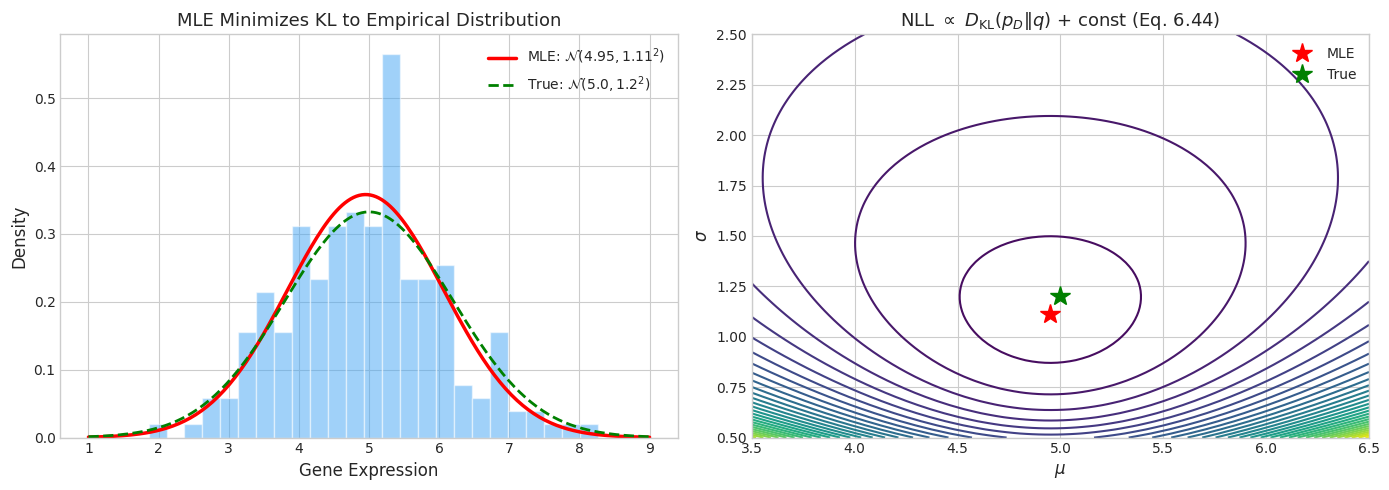

MLE: mu = 4.951, sigma = 1.114
True: mu = 5.000, sigma = 1.200


In [5]:
# Demonstrate: MLE minimizes KL divergence to the empirical distribution
# Generate gene expression data from a known Gaussian
np.random.seed(42)
mu_true, sigma_true = 5.0, 1.2
data = np.random.normal(mu_true, sigma_true, 200)

# MLE estimates
mu_mle = data.mean()
sigma_mle = data.std()

# Compute NLL (= KL + const) for a grid of (mu, sigma)
mu_grid = np.linspace(3.5, 6.5, 100)
sigma_grid = np.linspace(0.5, 2.5, 100)
MU, SIGMA = np.meshgrid(mu_grid, sigma_grid)
NLL = np.zeros_like(MU)

for i in range(len(sigma_grid)):
    for j in range(len(mu_grid)):
        NLL[i, j] = -np.mean(stats.norm.logpdf(data, MU[i, j], SIGMA[i, j]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: data histogram and fitted Gaussian
axes[0].hist(data, bins=25, density=True, alpha=0.5, color='#42A5F5', edgecolor='white')
x_plot = np.linspace(1, 9, 200)
axes[0].plot(x_plot, stats.norm.pdf(x_plot, mu_mle, sigma_mle), 'r-', linewidth=2.5,
            label=f'MLE: $\\mathcal{{N}}({mu_mle:.2f}, {sigma_mle:.2f}^2)$')
axes[0].plot(x_plot, stats.norm.pdf(x_plot, mu_true, sigma_true), 'g--', linewidth=2,
            label=f'True: $\\mathcal{{N}}({mu_true}, {sigma_true}^2)$')
axes[0].set_xlabel('Gene Expression', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('MLE Minimizes KL to Empirical Distribution', fontsize=13)
axes[0].legend(fontsize=10)

# Right: NLL surface
cs = axes[1].contour(MU, SIGMA, NLL, levels=30, cmap='viridis')
axes[1].plot(mu_mle, sigma_mle, 'r*', markersize=15, zorder=5, label='MLE')
axes[1].plot(mu_true, sigma_true, 'g*', markersize=15, zorder=5, label='True')
axes[1].set_xlabel('$\\mu$', fontsize=12)
axes[1].set_ylabel('$\\sigma$', fontsize=12)
axes[1].set_title('NLL $\\propto$ $D_{\\mathrm{KL}}(p_D \\| q)$ + const (Eq. 6.44)', fontsize=13)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f'MLE: mu = {mu_mle:.3f}, sigma = {sigma_mle:.3f}')
print(f'True: mu = {mu_true:.3f}, sigma = {sigma_true:.3f}')

## 13. Forward vs Reverse KL (Section 6.2.6)

When approximating a complex distribution $p$ with a simpler $q$:

**Forward KL** (M-projection, Eq. 6.45): $D_{\text{KL}}(p \| q)$ — minimizing forces $q$ to **cover** all modes of $p$ (zero-avoiding / mode-covering).

**Reverse KL** (I-projection, Eq. 6.46): $D_{\text{KL}}(q \| p)$ — minimizing forces $q$ to **concentrate** on one mode (zero-forcing / mode-seeking).

This distinction is critical in variational inference, where we choose a simple $q$ to approximate a complex posterior $p$.

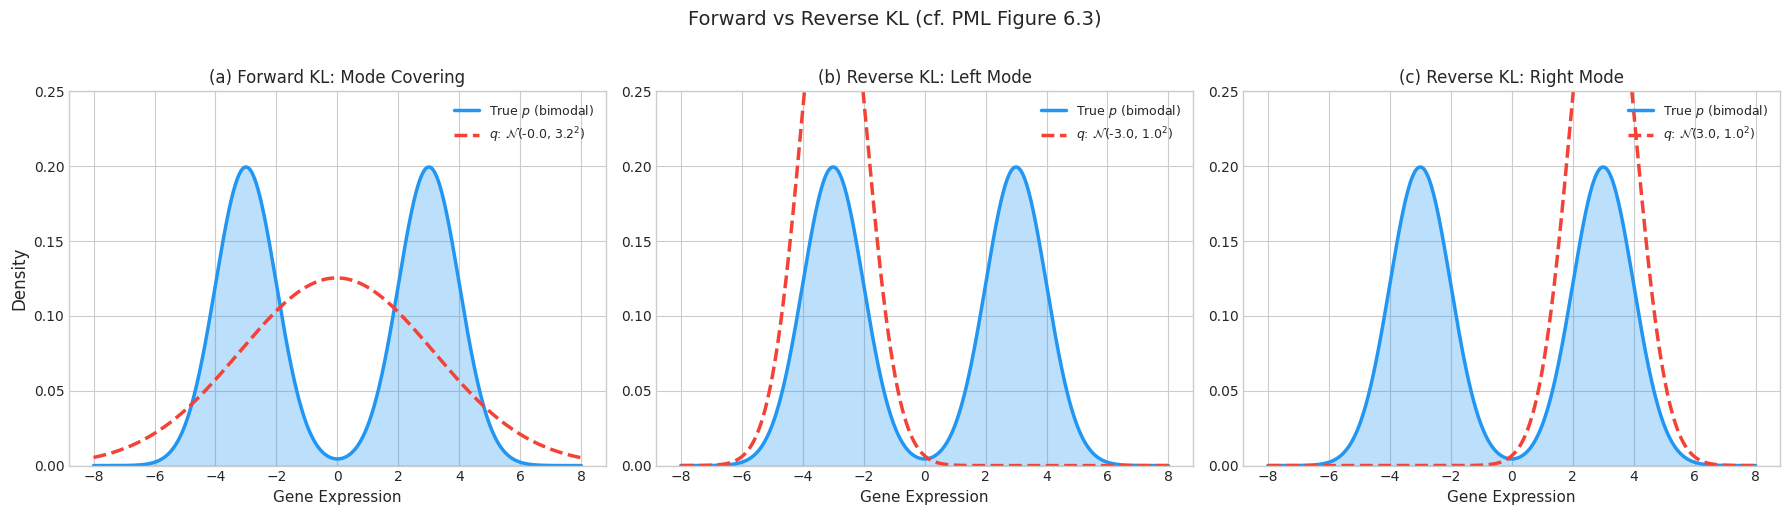

Forward KL: q covers both modes → broad, mode-covering approximation.
Reverse KL: q locks onto a single mode → narrow, mode-seeking approximation.


In [6]:
# Bimodal target: mixture of two Gaussians (two cell subpopulations)
def bimodal_pdf(x, mu1=-3, mu2=3, sigma=1.0, w1=0.5):
    return w1 * stats.norm.pdf(x, mu1, sigma) + (1 - w1) * stats.norm.pdf(x, mu2, sigma)


def forward_kl_gaussian_approx(x_grid, p_vals, mu, sigma):
    """Approximate forward KL: D_KL(p || q) on a grid."""
    q_vals = stats.norm.pdf(x_grid, mu, sigma)
    q_vals = np.clip(q_vals, 1e-15, None)
    mask = p_vals > 1e-15
    dx = x_grid[1] - x_grid[0]
    return np.sum(p_vals[mask] * np.log(p_vals[mask] / q_vals[mask])) * dx


def reverse_kl_gaussian_approx(x_grid, p_vals, mu, sigma):
    """Approximate reverse KL: D_KL(q || p) on a grid."""
    q_vals = stats.norm.pdf(x_grid, mu, sigma)
    p_vals_clipped = np.clip(p_vals, 1e-15, None)
    mask = q_vals > 1e-15
    dx = x_grid[1] - x_grid[0]
    return np.sum(q_vals[mask] * np.log(q_vals[mask] / p_vals_clipped[mask])) * dx


x_grid = np.linspace(-8, 8, 1000)
p_vals = bimodal_pdf(x_grid)

# Optimize forward KL over a grid of (mu, sigma)
mu_search = np.linspace(-5, 5, 200)
sigma_search = np.linspace(0.5, 5, 100)

# Forward KL: find best single Gaussian
best_fwd = {'kl': np.inf}
for mu_s in mu_search:
    for sig_s in sigma_search:
        kl = forward_kl_gaussian_approx(x_grid, p_vals, mu_s, sig_s)
        if kl < best_fwd['kl']:
            best_fwd = {'mu': mu_s, 'sigma': sig_s, 'kl': kl}

# Reverse KL: finds mode-seeking solutions
best_rev = []
for mu_init in [-3, 3]:  # start near each mode
    best = {'kl': np.inf}
    for sig_s in sigma_search:
        for mu_s in np.linspace(mu_init - 2, mu_init + 2, 100):
            kl = reverse_kl_gaussian_approx(x_grid, p_vals, mu_s, sig_s)
            if kl < best['kl']:
                best = {'mu': mu_s, 'sigma': sig_s, 'kl': kl}
    best_rev.append(best)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = [
    f'(a) Forward KL: Mode Covering',
    f'(b) Reverse KL: Left Mode',
    f'(c) Reverse KL: Right Mode',
]
approxes = [
    best_fwd,
    best_rev[0],
    best_rev[1],
]

for ax, title, approx in zip(axes, titles, approxes):
    ax.fill_between(x_grid, p_vals, alpha=0.3, color='#2196F3')
    ax.plot(x_grid, p_vals, '#2196F3', linewidth=2.5, label='True $p$ (bimodal)')
    q_vals = stats.norm.pdf(x_grid, approx['mu'], approx['sigma'])
    ax.plot(x_grid, q_vals, '#F44336', linewidth=2.5, linestyle='--',
           label=f'$q$: $\\mathcal{{N}}$({approx["mu"]:.1f}, {approx["sigma"]:.1f}$^2$)')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Gene Expression', fontsize=11)
    ax.legend(fontsize=9, loc='upper right')
    ax.set_ylim(0, 0.25)

axes[0].set_ylabel('Density', fontsize=12)
plt.suptitle('Forward vs Reverse KL (cf. PML Figure 6.3)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Forward KL: q covers both modes → broad, mode-covering approximation.')
print('Reverse KL: q locks onto a single mode → narrow, mode-seeking approximation.')

## Summary

- **KL divergence** $D_{\text{KL}}(p \| q) \geq 0$ measures the "extra bits" from using code $q$ instead of optimal code $p$
- KL is **not symmetric**: $D_{\text{KL}}(p \| q) \neq D_{\text{KL}}(q \| p)$
- **Jensen's inequality** proves non-negativity: $-\log$ is convex, so $E[\log(q/p)] \leq \log E[q/p] = 0$
- **Corollary**: the uniform distribution maximizes entropy
- For **Gaussians**, KL has a closed form involving means and variances (Eq. 6.33)
- **KL and MLE**: minimizing KL to the empirical distribution = maximizing likelihood (Eq. 6.44)
- **Forward KL** ($D_{\text{KL}}(p \| q)$) is mode-covering — $q$ spreads to cover all of $p$
- **Reverse KL** ($D_{\text{KL}}(q \| p)$) is mode-seeking — $q$ locks onto a single mode of $p$